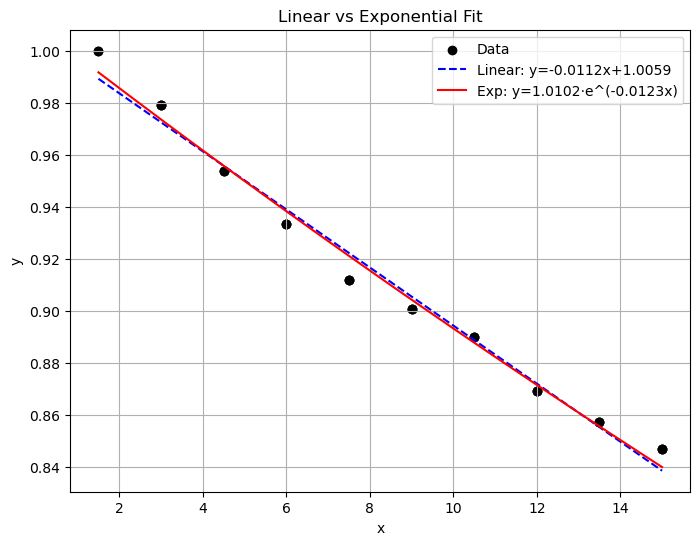

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit

# --- Your data ---
x = np.array([ 3., 4.5, 6., 7.5, 9., 10.5, 12., 13.5, 15., 
               1.5, 3., 4.5, 6., 7.5, 9., 10.5, 12., 13.5, 15.,
               1.5, 3., 4.5, 6., 7.5, 9., 10.5, 12., 13.5, 15. ])

y = np.array([0.97915743, 0.95369268, 0.93359568, 0.91198342, 0.90061782, 
              0.88992197, 0.86941083, 0.85729507, 0.84704208, 1.,
              0.97915743, 0.95369268, 0.93359568, 0.91198342, 0.90061782,
              0.88992197, 0.86941083, 0.85729507, 0.84704208, 1.,
              0.97915743, 0.95369268, 0.93359568, 0.91198342, 0.90061782,
              0.88992197, 0.86941083, 0.85729507, 0.84704208])

# --- Define models ---
def linear_func(x, m, c):
    return m*x + c

def exp_func(x, A, b):
    return A * np.exp(b * x)

# --- Fit models ---
popt_lin, _ = curve_fit(linear_func, x, y)
popt_exp, _ = curve_fit(exp_func, x, y, maxfev=5000)

# --- Generate smooth x for plotting ---
x_smooth = np.linspace(min(x), max(x), 500)

# --- Plot ---
plt.figure(figsize=(8,6))
plt.scatter(x, y, color="black", label="Data")

# Linear fit
plt.plot(x_smooth, linear_func(x_smooth, *popt_lin), "b--", 
         label=f"Linear: y={popt_lin[0]:.4f}x+{popt_lin[1]:.4f}")

# Exponential fit
plt.plot(x_smooth, exp_func(x_smooth, *popt_exp), "r-", 
         label=f"Exp: y={popt_exp[0]:.4f}·e^({popt_exp[1]:.4f}x)")

plt.xlabel("x")
plt.ylabel("y")
plt.title("Linear vs Exponential Fit")
plt.legend()
plt.grid(True)
plt.show()
